In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# gamma函数

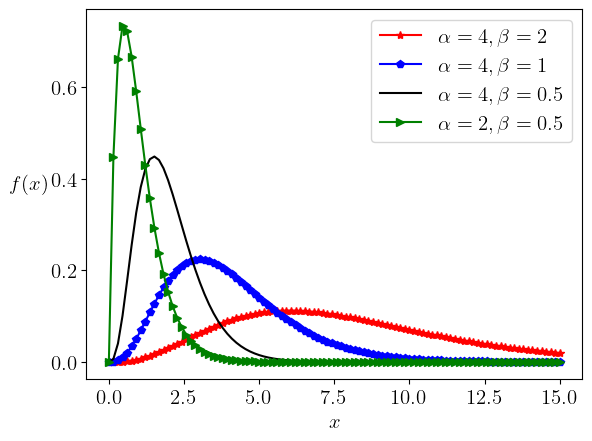

In [3]:
x = np.linspace(0, 15, 100)
plt.rc('font', size=15)
plt.rc('text', usetex=True)
plt.plot(x, stats.gamma.pdf(x, 4, 0, 2), 'r*-', label="$\\alpha=4, \\beta=2$")
plt.plot(x, stats.gamma.pdf(x, 4, 0, 1), 'bp-', label="$\\alpha=4, \\beta=1$")
plt.plot(x, stats.gamma.pdf(x, 4, 0, 0.5), 'k-', label="$\\alpha=4, \\beta=0.5$")
plt.plot(x, stats.gamma.pdf(x, 2, 0, 0.5), '>g-', label="$\\alpha=2, \\beta=0.5$")
plt.legend()
plt.xlabel('$x$')
plt.ylabel('$f(x)$', rotation=0, labelpad=15)
plt.savefig('gamma.png', dpi=1500)
plt.show()

# 正态函数

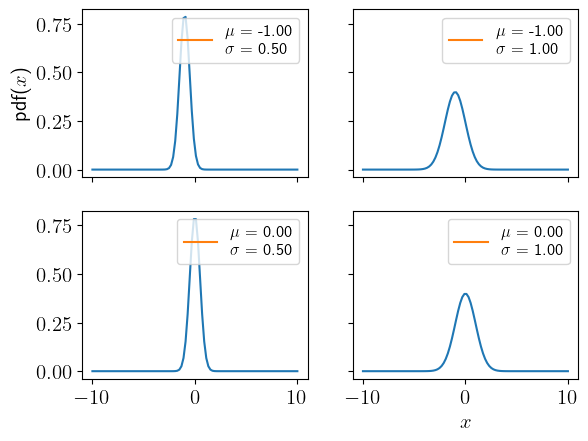

In [8]:
mu0 = [-1, 0]
s0 = [0.5, 1]
x = np.linspace(-10, 10, 100)
plt.rc('font', size=15)
plt.rc('text', usetex=True)
plt.rc('axes', unicode_minus=False)
# sharex=True / sharey=True 让 4 张子图共用同一套 x、y 轴刻度，缩放时保持同步
# 返回值 f 是整个图窗（Figure），ax 是一个 2×2 的 NumPy 数组，里面每个元素就是一张子图
f, ax = plt.subplots(len(mu0), len(s0), sharex=True, sharey=True)
for i in range(2):    
    for j in range(2):
        mu = mu0[i]
        s = s0[j]
        y = stats.norm(mu, s).pdf(x)
        ax[i, j].plot(x, y)
        ax[i, j].plot(1, 0, label="$\\mu$ = {:3.2f}\n$\\sigma$ = {:3.2f}".format(mu, s))
        ax[i, j].legend(fontsize=12)
ax[1, 1].set_xlabel('$x$')
ax[0, 0].set_ylabel('pdf($x$)')
plt.savefig('norm.png', dpi=1500)
plt.show()

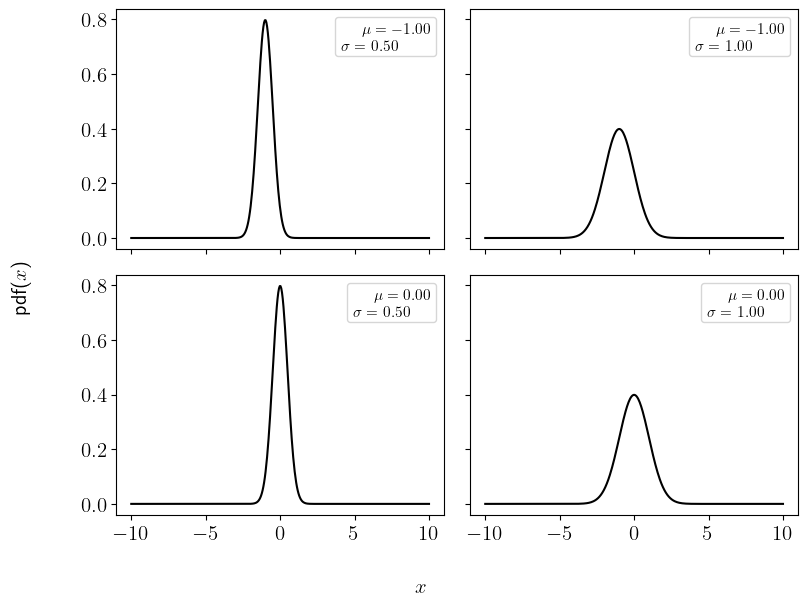

In [16]:
mu0 = [-1, 0]
s0  = [0.5, 1]
x = np.linspace(-10, 10, 400)

# 全局 rc 设置
plt.rc('font', size=15)
plt.rc('text', usetex=True)
plt.rc('axes', unicode_minus=False)

# 2×2 子图
fig, ax = plt.subplots(2, 2, figsize=(8, 6), sharex=True, sharey=True)

for i, mu in enumerate(mu0):
    for j, s in enumerate(s0):
        y = stats.norm(mu, s).pdf(x)
        ax[i, j].plot(x, y, color='black')
        ax[i, j].plot([], [],
              label=rf'$\mu={mu:.2f}\\ \sigma={s:.2f}$')
        ax[i, j].legend(handlelength=0, handletextpad=0, fontsize=11)

# 全局轴标签
# 方法签名：Figure.text(x, y, s, *, ha, va, fontsize)
# 在整个图窗坐标系 (0.5, 0.0)（下边缘中间）放横轴标签 “x”
# ha='center'：水平居中；va='center'：垂直居中
fig.text(0.5, 0.00, r'$x$', ha='center', va='center', fontsize=15)
fig.text(0.00, 0.5, r'pdf($x$)', ha='center', va='center',
         rotation='vertical', fontsize=15)
# 自动调整子图间距，防止标签重叠
plt.tight_layout()
# 手动再留出一点边距，确保全局轴标签不被裁剪
# 单位仍是图窗坐标系（比例）
plt.subplots_adjust(left=0.12, bottom=0.12)  # 给全局标签留位置
# bbox_inches='tight'：剪掉多余空白
plt.savefig('norm2.png', dpi=300, bbox_inches='tight')
plt.show()

# 二项分布（分布律）

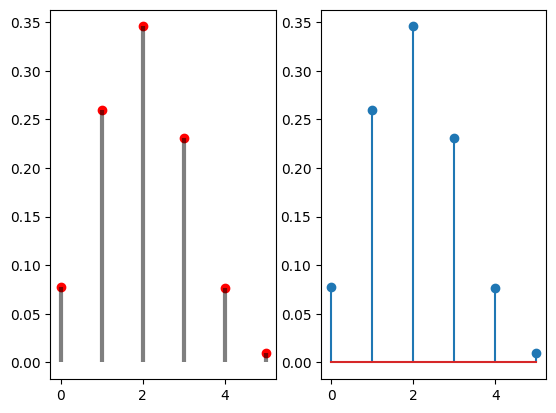

In [5]:
n, p = 5, 0.4
x = np.arange(6)
y = stats.binom.pmf(x, n, p)
plt.subplot(1, 2, 1)
plt.plot(x, y, 'ro')
# vlines(x, ymin, ymax) 画竖线图
# lw设置线宽度， alpha设置图的透明度
plt.vlines(x, 0, y, 'k', lw=3, alpha=0.5)
plt.subplot(1, 2, 2)
# 火柴棍图
plt.stem(x, y)
plt.savefig("binomial.png", dpi=500)
plt.show()